# E38 · Real-time epidemic tracking: is it growing right now?

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | The German COVID-19 hospitalisation **reporting triangle** from the COVID-19 Nowcast Hub (RKI data, reformatted by KIT): for every day, how many hospitalisations were added to the national data 0, 1, 2, ... 80 days later. National, all ages, 15 September 2021 to March 2022 (the Delta wave and the start of Omicron) |
| **You will learn** | Right truncation and the **reporting triangle** · rebuilding what was known on a past date ("vintages") · a **nowcast** as a model of the triangle: expected final counts x a reporting-delay distribution (discrete-time hazard with reporting-weekday and weekly-drifting effects) · the **renewal equation** $I_t = R_t \sum_s g_s I_{t-s}$ written as one **triangular solve** · generation-interval and infection-to-report delays · a spurious "the epidemic is shrinking" from right-truncated data, and its fix · why $R_t$ depends on the generation interval and the growth rate does not · a real **backtest** at five dates: interval coverage and **CRPS** against the "last reported" baseline · PPCs on the triangle · explaining it to everyone: a growth traffic light and real-time dials, an icon array of the not-yet-reported, an animation of the fog lifting, a quantile dotplot of next week |

## The question, in one paragraph

Every morning during the pandemic, officials had to decide *today* whether things were
getting better or worse. The newest numbers are always the most important and always the
most wrong: a hospital admission on Monday may not reach the national figures until the
following week, or the week after. So the last few days on every chart are too low, and the
chart always seems to say "it is falling" - even in the middle of a surge. **How do we see
through that fog, and how sure can we be, on a given day, that the epidemic is growing?**
We answer with Germany's own record of how its COVID-19 hospital numbers trickled in during
the winter of 2021/22, and we check every answer against what was eventually reported.

## The technical plan

Two problems stacked on each other. **Nowcasting**: estimate the counts that will eventually
be reported for recent days from the part reported so far, using how reports have trickled
in before (Höhle & an der Heiden 2014, *Biometrics*; the `epinowcast` R package; the German
Nowcast Hub, Wolffram et al. 2023, *PLOS Computational Biology*, whose data we use). And
**transmission**: turn the (nowcast) hospitalisations into infections and a time-varying
reproduction number $R_t$ with the **renewal equation** (Cori et al. 2013, *American Journal
of Epidemiology*; Gostic et al. 2020, *PLOS Computational Biology*). We fit both in one
Bayesian model, so the uncertainty about what has not been reported yet flows into the
answer to "is it growing?".

In [1]:
import json
import logging
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
import pymc as pm
import pytensor.tensor as pt
from IPython.display import HTML, display
import matplotlib.dates as mdates
from matplotlib import animation
from matplotlib.patches import Ellipse, Rectangle, Wedge
from scipy import stats

from pymc_challenges import data

RANDOM_SEED = 2022
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
pio.renderers.default = "plotly_mimetype+notebook_connected"
logging.getLogger("pymc").setLevel(logging.WARNING)

# Grey for what was known at the time, black for the eventual truth, one hue per model.
KNOWN, TRUTH, NOWC, NAIVE, GREY = "#8a8a86", "#222222", "#2a78d6", "#d6452a", "#c8c8c4"
GROW, FLAT, SHRINK = "#d6452a", "#e8b422", "#1baf7a"


def date_axis(ax):
    """Compact date ticks (the default labels overlap on long daily series)."""
    loc = mdates.AutoDateLocator(maxticks=8)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))


def in_ten(p):
    """A probability in words, never claiming certainty."""
    return "more than 9 in 10" if p >= 0.95 else "fewer than 1 in 10" if p <= 0.05 else f"{round(p * 10):.0f} in 10"


print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The data: a reporting triangle

The Robert Koch Institute (RKI) published, every day, the number of COVID-19 hospitalisations
by **Meldedatum** - the date the underlying *case* was reported to the local health
authority. A case reported on Monday may be admitted to hospital days later, and the
admission then takes more days to travel up to the national data, so the count for any
Meldedatum keeps growing for weeks. The Nowcast Hub rebuilt this from the daily RKI files as a
**reporting triangle**: one row per Meldedatum, and in column `value_kd` the hospitalisations
for that date that were *added* $k$ days later.

In [2]:
data.describe("covid_hosp_triangle_de")
raw = data.load("covid_hosp_triangle_de")
de = raw[(raw.location == "DE") & (raw.age_group == "00+")].copy()
de.index = pd.to_datetime(de.pop("date"))
de = de.drop(columns=["location", "age_group"]).sort_index()
print(de.shape, de.index.min().date(), "to", de.index.max().date())
de.loc["2021-11-24":"2021-11-26", "value_0d":"value_9d"]

covid_hosp_triangle_de: Reporting triangle of COVID-19 hospitalisations in Germany, 2021-04-06 to 2024: one row per Meldedatum (date the case was reported to the health authority) x location (DE and 16 states) x age group (00+ = all ages); value_kd = hospitalisations of those cases that were added to the data k days after the Meldedatum (k = 0..80, then value_>80d). Negative corrections have been redistributed to earlier delays by the hub.
  source: German COVID-19 Nowcast Hub (KIT / Wolffram et al. 2023, PLOS Computational Biology 19:e1011394), reformatted from the Robert Koch Institute's daily 'COVID-19-Hospitalisierungen in Deutschland' releases (github.com/robert-koch-institut).
  url:    https://raw.githubusercontent.com/KITmetricslab/hospitalization-nowcast-hub/main/data-truth/COVID-19/COVID-19_hospitalizations_preprocessed.csv


(1355, 82) 2021-04-06 to 2024-12-20


,value_0d,value_1d,value_2d,value_3d,value_4d,value_5d,value_6d,value_7d,value_8d,value_9d
date,,,,,,,,,,
2021-11-24,425,292.0,220.0,132.0,44.0,32.0,134.0,103.0,81.0,73.0
2021-11-25,343,296.0,183.0,41.0,44.0,152.0,111.0,70.0,105.0,68.0
2021-11-26,353,272.0,69.0,29.0,142.0,113.0,93.0,104.0,66.0,28.0


For 24 November 2021, 425 hospitalisations were known on the day itself, 292 more arrived the
next day, and so on. How long do we have to wait? We cut the triangle at a maximum delay
$D = 40$ days: the "final" count for a date is what was reported within 40 days. The next cell
measures what that misses.

In [3]:
D = 40
DELAY_COLS = [f"value_{k}d" for k in range(D + 1)]
START, ASOF = pd.Timestamp("2021-09-15"), pd.Timestamp("2022-01-27")
window = de.loc[START:"2022-03-31"]
share_40 = window[DELAY_COLS].sum(axis=1) / window.sum(axis=1)
print(f"share of all eventual reports that arrive within {D} days: median {share_40.median():.3f}, "
      f"10-90% over dates {share_40.quantile(0.1):.3f}-{share_40.quantile(0.9):.3f}")
FINAL = de[DELAY_COLS].sum(axis=1)  # our "final" count for each Meldedatum


def triangle_as_of(asof, start=START):
    """The triangle for Meldedatum start..asof, and the mask of cells known on `asof`."""
    V = de.loc[start:asof, DELAY_COLS].to_numpy(float)
    T = len(V)
    known = np.arange(T)[:, None] + np.arange(D + 1)[None, :] <= T - 1
    return V, known


def reported_by(asof, start=START):
    """What the national series looked like on `asof`: per Meldedatum, the total reported so far."""
    V, known = triangle_as_of(asof, start)
    return pd.Series((V * known).sum(axis=1), index=pd.date_range(start, asof))

share of all eventual reports that arrive within 40 days: median 0.941, 10-90% over dates 0.906-0.973


About 94% of all reports arrive within 40 days (91-97% for most dates), so the truncation
costs us a few per cent of a very long tail, the same for every analysis below.

**Vintages.** Cutting the triangle at the diagonal $\text{Meldedatum} + k \le$ *as-of date* gives
back what the national series looked like on that date - with one caveat: the hub
redistributed the occasional negative correction to earlier delays, so this is very close to,
not identical with, the figure RKI published that morning.

median share reported after 0, 1, 7, 14, 21 days: [0.22 0.38 0.75 0.9  0.96]


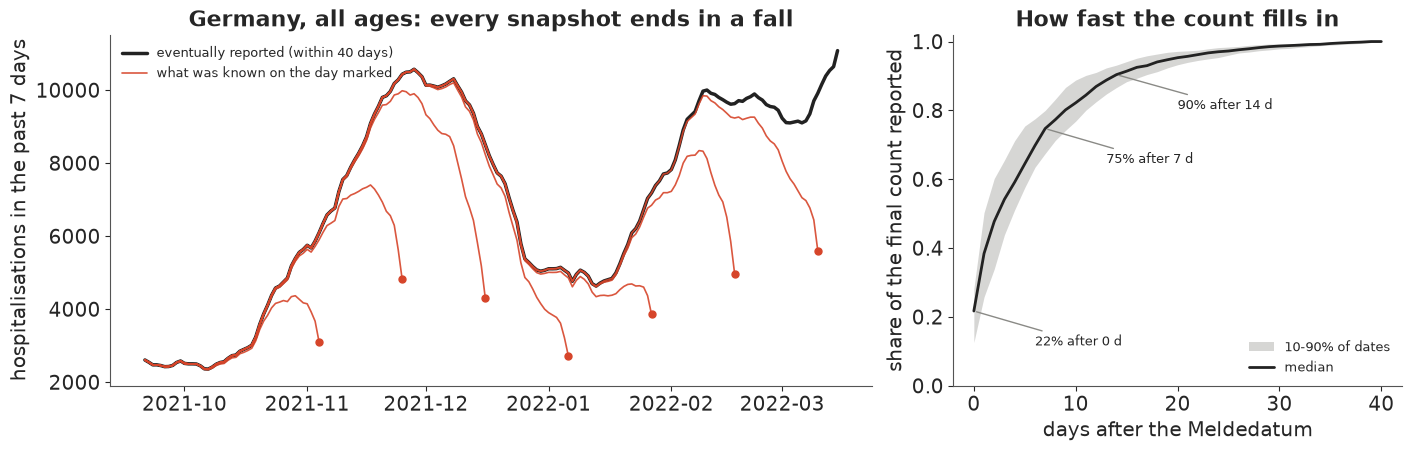

In [4]:
k7 = np.ones(7)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={"width_ratios": [1.7, 1]})
ax = axes[0]
final7 = FINAL.loc[START:"2022-03-15"].rolling(7).sum()
ax.plot(final7.index, final7, color=TRUTH, lw=2.5, label="eventually reported (within 40 days)")
for i, a in enumerate(pd.date_range("2021-11-04", "2022-03-10", freq="3W-THU")):
    seen7 = reported_by(a).rolling(7).sum()
    ax.plot(seen7.index, seen7, color=NAIVE, lw=1.2, alpha=0.9,
            label="what was known on the day marked" if i == 0 else None)
    ax.plot(a, seen7.iloc[-1], "o", color=NAIVE, ms=5)
ax.set(ylabel="hospitalisations in the past 7 days", title="Germany, all ages: every snapshot ends in a fall")
ax.legend(loc="upper left", fontsize=9)
ax = axes[1]
Vw, _ = triangle_as_of("2021-12-18")  # dates with all 40 delays known by 27 January
cum = np.cumsum(Vw, axis=1) / Vw.sum(axis=1, keepdims=True)
lo, med, hi = np.quantile(cum, [0.1, 0.5, 0.9], axis=0)
ax.fill_between(np.arange(D + 1), lo, hi, color=KNOWN, alpha=0.35, lw=0, label="10-90% of dates")
ax.plot(np.arange(D + 1), med, color=TRUTH, lw=2, label="median")
for dd in [0, 7, 14]:
    ax.annotate(f"{med[dd]:.0%} after {dd} d", (dd, med[dd]), xytext=(dd + 6, med[dd] - 0.1), fontsize=9,
                arrowprops=dict(arrowstyle="-", color=KNOWN))
ax.set(xlabel="days after the Meldedatum", ylabel="share of the final count reported",
       title="How fast the count fills in", ylim=(0, 1.02))
ax.legend(loc="lower right", fontsize=9)
print("median share reported after 0, 1, 7, 14, 21 days:", np.round(med[[0, 1, 7, 14, 21]], 2));

The left panel is the whole problem in one picture. Each red curve is the 7-day
hospitalisation count *as it looked on the date marked by the dot*; the black curve is what
was eventually reported. **Every snapshot bends down at its end**, whether the epidemic was
rising (early November, late January), peaking (late November) or falling (mid-December).
The right panel shows why: on the day itself only about a fifth of the eventual count is
known, after a week about three quarters, and it takes two weeks to reach 90%.

> **In plain words:** On any given day, the most recent week of hospital numbers is only
> about half complete. That makes every live chart look as if things are improving, even
> when they are getting worse.

## 2 · What the delays look like: weekdays everywhere

Two calendar effects are visible straight from the triangle: fewer cases are *reported to
health authorities* on weekends (a Meldedatum effect), and fewer hospitalisations are *added
to the data* on weekends (a reporting-day effect).

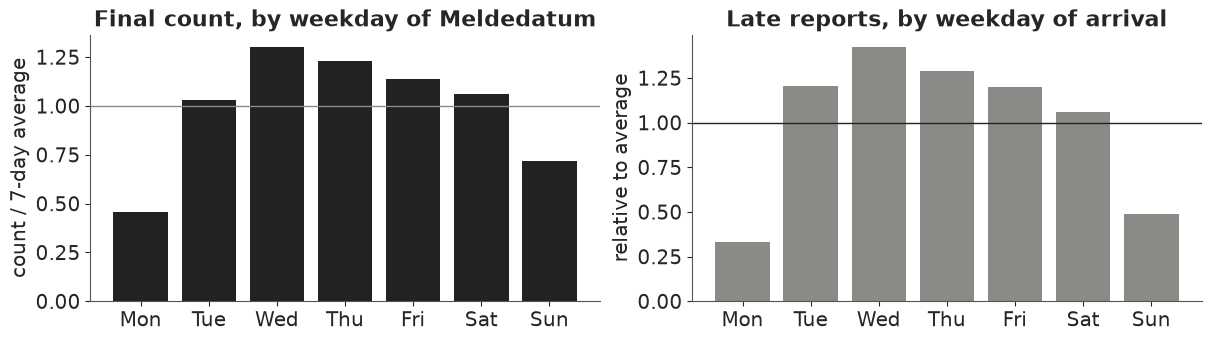

In [5]:
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
Vall, known_all = triangle_as_of(ASOF)
dates_all = pd.date_range(START, ASOF)
full_rows = known_all.all(axis=1)
tot = Vall[full_rows].sum(axis=1)
by_ref = pd.Series(tot / pd.Series(tot).rolling(7, center=True, min_periods=4).mean().to_numpy(),
                   index=dates_all[full_rows]).groupby(dates_all[full_rows].dayofweek).mean()
rep_day = (dates_all.dayofweek.to_numpy()[:, None] + np.arange(D + 1)[None, :]) % 7
added = pd.Series(Vall[known_all & (np.arange(D + 1) >= 1)[None, :]],
                  index=rep_day[known_all & (np.arange(D + 1) >= 1)[None, :]]).groupby(level=0).sum()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.3))
axes[0].bar(days, by_ref.to_numpy(), color=TRUTH)
axes[0].axhline(1, color=KNOWN, lw=1)
axes[0].set(ylabel="count / 7-day average", title="Final count, by weekday of Meldedatum")
axes[1].bar(days, added.to_numpy() / added.mean(), color=KNOWN)
axes[1].axhline(1, color=TRUTH, lw=1)
axes[1].set(ylabel="relative to average", title="Late reports, by weekday of arrival");

A Monday Meldedatum carries less than half the hospitalisations of an average day and a Sunday
about 70% (few cases are registered at weekends), and late reports arrive mostly Tuesday to
Saturday: whatever
happened on a Friday is still missing on Monday morning. A nowcast has to know both.

## 3 · The model: infections, reports, and the fog

We write down how the data came to be, from the back.

**Transmission (renewal equation).** Latent infections $I_t$ follow

$$I_t = R_t \sum_{s=1}^{14} g_s\, I_{t-s},$$

where $g_s$ is the **generation interval** - the probability that the time from infecting to
being infected is $s$ days - and $R_t$ is the time-varying reproduction number: the average
number of people each person infected at time $t$ goes on to infect. $\log R_t$ is a weekly
random walk (it may change once a week), and the process starts from 14 days of exponential
growth before the window.

**From infection to a hospitalisation on a Meldedatum.** Expected final hospitalisations
with Meldedatum $t$ are

$$\lambda_t = \Bigl(\sum_{k=0}^{20} f_k\, I_{t-k}\Bigr) \times e^{\delta_{\mathrm{wd}(t)}},$$

with $f_k$ the delay from infection to the case being reported (incubation plus testing) and
$\delta$ a zero-sum Meldedatum weekday effect. The share of infections that end in hospital
is absorbed into the scale of $I_t$ ("infections that will lead to a hospitalisation"), so
$R_t$ here describes those infections. When that share changes - and it fell when Omicron
replaced Delta - the change looks like a change in transmission. We come back to this.

**Reporting (the nowcast part).** Of those $\lambda_t$, a fraction $p_{t,d}$ is added $d$ days
later. We model it as a discrete-time **hazard**, the probability of being reported on day
$d$ given not yet reported:

$$\operatorname{logit} h_{t,d} = \gamma_d + \rho_{\mathrm{wd}(t+d)} + \beta_{\mathrm{week}(t)},\qquad
p_{t,d} = h_{t,d}\prod_{j<d}(1-h_{t,j}),\quad h_{t,D}=1,$$

with a smooth baseline $\gamma_d$ (a random walk over delays), a **reporting-weekday** effect
$\rho$ and a weekly random walk $\beta$ that lets reporting speed up or slow down over the
winter (close to the structure the `epinowcast` package uses). Each cell of the triangle is then

$$n_{t,d} \sim \operatorname{NegBinomial}(\lambda_t\, p_{t,d},\ \phi),$$

and only the cells known on the as-of date enter the likelihood. The nowcast of a recent
day is the part already reported plus draws of the missing cells.

**Fixed inputs.** The generation interval is a discretised gamma with mean 4.5 days (sd 2.5):
Ganyani et al. (2020, *Eurosurveillance*) estimated means of about 4 to 5 days from early
2020 transmission pairs, and later variants are generally thought to be somewhat faster; we
test 3 and 6 days in section 7. Infection to Meldedatum is a gamma with mean 6 days (sd 3):
a median incubation period of about 5 days (Lauer et al. 2020, *Annals of Internal
Medicine*) plus a day or so to a reported test. Both are assumptions, stated here so they can
be argued with.

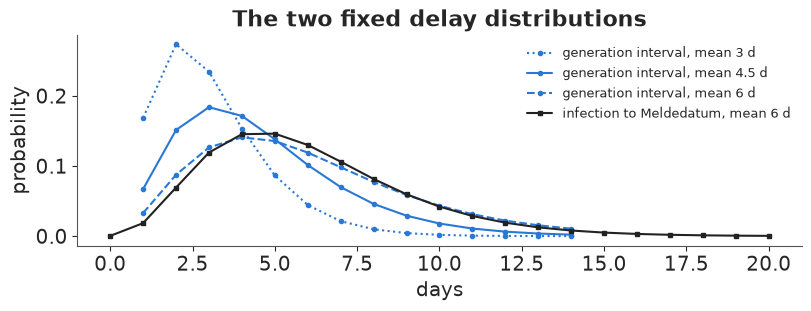

In [6]:
SMAX, KMAX = 14, 20
GI_MEAN, GI_SD = 4.5, 2.5


def discretised_gamma(mean, sd, lo, hi):
    """P(k) for k = lo..hi from a gamma(mean, sd) binned at k +- 0.5 and renormalised."""
    shape, scale = (mean / sd) ** 2, sd**2 / mean
    k = np.arange(lo, hi + 1)
    p = stats.gamma.cdf(k + 0.5, shape, scale=scale) - stats.gamma.cdf(np.maximum(k - 0.5, 0), shape, scale=scale)
    return p / p.sum()


def gen_interval(mean=GI_MEAN, sd=None):
    return discretised_gamma(mean, GI_SD * mean / GI_MEAN if sd is None else sd, 1, SMAX)  # g_1..g_14


INF_TO_REPORT = discretised_gamma(6.0, 3.0, 0, KMAX)  # f_0..f_20

fig, ax = plt.subplots(figsize=(8, 3))
for m_, ls in [(3.0, ":"), (GI_MEAN, "-"), (6.0, "--")]:
    ax.plot(np.arange(1, SMAX + 1), gen_interval(m_), "o" + ls, color=NOWC, ms=3, lw=1.5,
            label=f"generation interval, mean {m_:g} d")
ax.plot(np.arange(KMAX + 1), INF_TO_REPORT, "s-", color=TRUTH, ms=3, lw=1.5, label="infection to Meldedatum, mean 6 d")
ax.set(xlabel="days", ylabel="probability", title="The two fixed delay distributions")
ax.legend(fontsize=9);

**Implementing the renewal equation as one linear solve.** The usual implementation is a loop
(`pytensor.scan`) over days. But for given $R_t$ the equation is *linear* in the infections:
stacking the unknown $I_t$ into a vector $x$,

$$\bigl(\mathbb{1} - \operatorname{diag}(R)\,G\bigr)\,x = \operatorname{diag}(R)\,G_{\text{seed}}\,I_{\text{seed}},$$

where $G$ is the strictly lower-triangular Toeplitz matrix of $g_s$ and $G_{\text{seed}}$ applies
the generation interval to the seeding days. The matrix is lower triangular, so
`pt.linalg.solve_triangular` performs exactly the forward recursion, with a cheap gradient and
no Python-level loop. First we check it against the loop, in NumPy.

In [7]:
def renewal_matrices(T, g):
    """G (M x M), G_seed (M x SMAX) and the infection -> Meldedatum convolution F (T x M), M = T + KMAX."""
    M = T + KMAX
    G = sum(np.eye(M, k=-s) * g[s - 1] for s in range(1, SMAX + 1))
    lag = np.arange(M)[:, None] + SMAX - np.arange(SMAX)[None, :]
    G_seed = np.where((lag >= 1) & (lag <= SMAX), g[np.clip(lag - 1, 0, SMAX - 1)], 0.0)
    F = np.zeros((T, M))
    for k in range(KMAX + 1):
        F[np.arange(T), np.arange(T) + KMAX - k] = INF_TO_REPORT[k]
    return G, G_seed, F


def renewal_loop(R, seed, g):
    I = list(seed)
    for r in R:
        I.append(r * sum(g[s - 1] * I[-s] for s in range(1, SMAX + 1)))
    return np.array(I[len(seed):])


g_test = gen_interval()
R_test = np.exp(np.cumsum(rng.normal(0, 0.05, 60)))
seed_test = np.exp(0.03 * np.arange(-SMAX, 0)) * 100
G_t, Gs_t, _ = renewal_matrices(60 - KMAX, g_test)
x_solve = np.linalg.solve(np.eye(60) - R_test[:, None] * G_t, R_test * (Gs_t @ seed_test))
print("triangular solve == loop:", np.allclose(x_solve, renewal_loop(R_test, seed_test, g_test)))

triangular solve == loop: True


Now the PyMC model. One function builds three variants: the **nowcast** model (the full
triangle likelihood above), a **naive** model that feeds the renewal equation the totals
reported so far as if they were final, and the same naive model on **complete** data (used as
"hindsight" later). Everything else - the renewal equation, priors, weekday effect - is
shared. A few implementation notes: the weekly random walk on $\log R_t$ is *centred*
(`pm.GaussianRandomWalk`), which the data inform so strongly that the non-centred version
needs trees of 1,000 leapfrog steps; nutpie's **low-rank** mass matrix adaptation handles the
remaining correlations between the weeks; and the delay probabilities are computed on the
log scale with `softplus`.

In [8]:
def build_model(V, known, start, gi_mean=GI_MEAN, likelihood="nowcast"):
    """likelihood: 'nowcast' (triangle cells), 'naive' (totals so far, treated as final)."""
    T = len(V)
    dates = pd.date_range(start, periods=T)
    G, G_seed, F = renewal_matrices(T, gen_interval(gi_mean))
    M = T + KMAX
    inf_dates = pd.date_range(start - pd.Timedelta(days=KMAX), periods=M)
    week = np.arange(M) // 7
    wd = dates.dayofweek.to_numpy()
    coords = {"date": dates, "inf_date": inf_dates, "weekday": days, "delay": np.arange(D + 1),
              "rw_week": np.arange(week[-1] + 1)}
    with pm.Model(coords=coords) as model:
        # seeding: 14 days of exponential growth before the first modelled infection
        log_seed = pm.Normal("log_seed", np.log(V[:7].sum(axis=1).mean()), 1.0)
        seed_growth = pm.Normal("seed_growth", 0.0, 0.05)
        seed = pt.exp(log_seed + seed_growth * np.arange(-SMAX, 0))
        # log R_t: weekly random walk, centred
        sigma_R = pm.HalfNormal("sigma_R", 0.15)
        log_R_week = pm.GaussianRandomWalk("log_R_week", mu=0.0, sigma=sigma_R,
                                           init_dist=pm.Normal.dist(0.0, 0.3), dims="rw_week")
        R = pm.Deterministic("R", pt.exp(log_R_week[week]), dims="inf_date")
        # renewal equation as a lower-triangular solve
        A = pt.eye(M) - R[:, None] * G
        infections = pm.Deterministic(
            "infections", pt.linalg.solve_triangular(A, R * pt.dot(G_seed, seed), lower=True), dims="inf_date")
        dow = pm.ZeroSumNormal("dow", sigma=0.5, dims="weekday")
        lam = pm.Deterministic("lam", pt.dot(F, infections) * pt.exp(dow[wd]), dims="date")
        inv_sqrt_phi = pm.HalfNormal("inv_sqrt_phi", 0.3)
        phi = 1 / inv_sqrt_phi**2
        if likelihood == "naive":
            pm.NegativeBinomial("y", mu=lam, alpha=phi, observed=(V * known).sum(axis=1), dims="date")
            return model
        # reporting-delay hazard
        gamma0 = pm.Normal("gamma0", -1.3, 1.0)
        sigma_gamma = pm.HalfNormal("sigma_gamma", 0.5)
        gamma_z = pm.Normal("gamma_z", 0.0, 1.0, shape=D - 1)
        gamma = pm.Deterministic("gamma", gamma0 + pt.concatenate([pt.zeros(1), pt.cumsum(sigma_gamma * gamma_z)]))
        rho = pm.ZeroSumNormal("rho", sigma=1.0, dims="weekday")
        sigma_beta = pm.HalfNormal("sigma_beta", 0.2)
        n_ref_weeks = int(np.ceil(T / 7))
        beta = pm.GaussianRandomWalk("beta", mu=0.0, sigma=sigma_beta, init_dist=pm.Normal.dist(0.0, 0.01),
                                     steps=n_ref_weeks - 1)
        rep_wd = (wd[:, None] + np.arange(D)[None, :]) % 7
        logit_h = gamma[None, :] + rho[rep_wd] + beta[np.arange(T) // 7][:, None]
        log_h, log_1mh = -pt.softplus(-logit_h), -pt.softplus(logit_h)
        log_p = (pt.concatenate([log_h, pt.zeros((T, 1))], axis=1)
                 + pt.concatenate([pt.zeros((T, 1)), pt.cumsum(log_1mh, axis=1)], axis=1))
        ti, di = np.nonzero(known)
        pm.NegativeBinomial("n", mu=pt.exp(pt.log(lam)[ti] + log_p[ti, di]), alpha=phi, observed=V[known])
    return model


KEEP = ["sigma_R", "log_R_week", "R", "infections", "lam", "dow", "inv_sqrt_phi", "log_seed", "seed_growth"]
KEEP_NOWCAST = KEEP + ["gamma", "rho", "beta", "sigma_beta", "sigma_gamma"]


def fit(model, draws=1000, target_accept=0.9, seed=RANDOM_SEED):
    names = [v for v in KEEP_NOWCAST if v in model.named_vars]
    with model:
        return pm.sample(draws=draws, random_seed=seed, progressbar=False, target_accept=target_accept,
                         nuts={"adaptation": "low_rank"}, var_names=names)


def diagnose(idata, label, var_names=("sigma_R", "log_R_week", "lam")):
    ss = idata.sample_stats
    worst = {v: (float(az.rhat(idata, var_names=[v])[v].max()), float(az.ess(idata, var_names=[v])[v].min()))
             for v in var_names}
    print(f"{label}: divergences {int(ss['diverging'].sum())}, tuning steps {idata.posterior.attrs.get('tuning_steps')}, "
          f"median tree depth {np.median(ss['depth'].to_numpy()):.0f}; "
          + "; ".join(f"{v}: max r_hat {r:.3f}, min ESS {e:.0f}" for v, (r, e) in worst.items()))

**Prior predictive check.** Before fitting, what daily hospitalisation curves do these priors
allow? (The triangle likelihood cannot be forward-sampled cheaply cell by cell, so we look at
$\lambda_t$ and $R_t$ from the naive variant, which shares every prior of the transmission
part.)

prior share of curves whose peak day exceeds 100,000 hospitalisations: 0.37


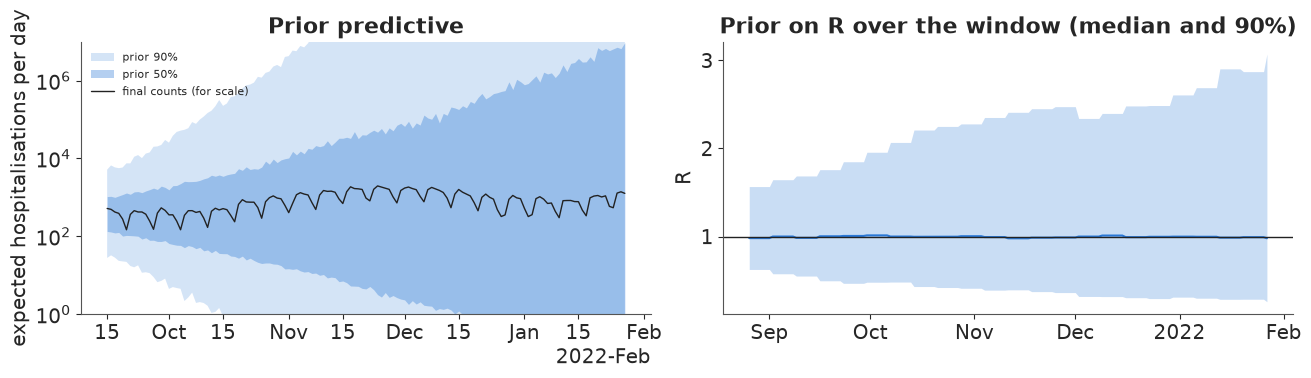

In [9]:
V_main, known_main = triangle_as_of(ASOF)
with build_model(V_main, known_main, START, likelihood="naive"):
    prior = pm.sample_prior_predictive(500, var_names=["lam", "R"], random_seed=RANDOM_SEED)
lam_prior = prior.prior["lam"].to_numpy().reshape(500, -1)
R_prior = prior.prior["R"].to_numpy().reshape(500, -1)
q_lam = np.nanquantile(lam_prior, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
d_main = pd.date_range(START, ASOF)
axes[0].fill_between(d_main, q_lam[0], q_lam[4], color=NOWC, alpha=0.2, lw=0, label="prior 90%")
axes[0].fill_between(d_main, q_lam[1], q_lam[3], color=NOWC, alpha=0.35, lw=0, label="prior 50%")
axes[0].plot(d_main, FINAL.loc[START:ASOF], color=TRUTH, lw=1, label="final counts (for scale)")
axes[0].set(yscale="log", ylim=(1, 1e7), ylabel="expected hospitalisations per day", title="Prior predictive")
axes[0].legend(fontsize=8, loc="upper left")
inf_d = pd.date_range(START - pd.Timedelta(days=KMAX), periods=R_prior.shape[1])
qR = np.quantile(R_prior, [0.05, 0.5, 0.95], axis=0)
axes[1].fill_between(inf_d, qR[0], qR[2], color=NOWC, alpha=0.25, lw=0)
axes[1].plot(inf_d, qR[1], color=NOWC)
axes[1].axhline(1, color=TRUTH, lw=1)
axes[1].set(ylabel="R", title="Prior on R over the window (median and 90%)")
for ax in axes:
    date_axis(ax)
print(f"prior share of curves whose peak day exceeds 100,000 hospitalisations: {(lam_prior.max(axis=1) > 1e5).mean():.2f}")

The prior on $R$ alone looks modest - a median of 1 and a 90% range of roughly 0.3 to 3 by
the end of the window - but compounded through the renewal equation over four months it
allows anything from a handful to millions of hospitalisations a day (about a third of the
prior curves peak above 100,000 a day). That is deliberately vague about the *level*: the
triangle holds well over 100,000 hospitalisations, and the data, not the prior, will pin the
curve down. What the prior does encode is how $R$ moves: once a week, typically by 10-15%.

## 4 · Fitting on 27 January 2022: naive and nowcast

Stand on 27 January 2022. Omicron is spreading and the question of the day is whether
hospitalisations will follow. We fit both models to the triangle as it was known that day.

In [10]:
nowcast_idata = fit(build_model(V_main, known_main, START))
diagnose(nowcast_idata, "nowcast model", ("sigma_R", "log_R_week", "lam", "beta", "gamma"))
naive_idata = fit(build_model(V_main, known_main, START, likelihood="naive"))
diagnose(naive_idata, "naive model")
az.summary(nowcast_idata, var_names=["sigma_R", "inv_sqrt_phi", "sigma_gamma", "sigma_beta", "dow", "rho"], round_to=3)

nowcast model: divergences 1, tuning steps 800, median tree depth 4; sigma_R: max r_hat 1.001, min ESS 2809; log_R_week: max r_hat 1.003, min ESS 1043; lam: max r_hat 1.004, min ESS 4879; beta: max r_hat 1.003, min ESS 4746; gamma: max r_hat 1.006, min ESS 4440


naive model: divergences 0, tuning steps 800, median tree depth 4; sigma_R: max r_hat 1.001, min ESS 1306; log_R_week: max r_hat 1.004, min ESS 2531; lam: max r_hat 1.004, min ESS 3678


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_R,0.128,0.029,0.089,0.180,2809.487,2818.686,1.001,0.001,0.001
inv_sqrt_phi,0.241,0.006,0.231,0.251,7188.620,3417.563,1.001,0.000,0.000
sigma_gamma,0.142,0.019,0.114,0.174,782.679,846.041,1.006,0.001,0.001
sigma_beta,0.066,0.016,0.045,0.096,3187.001,2669.924,1.001,0.000,0.000
dow[Mon],-0.719,0.018,-0.748,-0.691,7081.736,2972.974,1.000,0.000,0.000
dow[Tue],0.075,0.016,0.051,0.100,8224.617,3349.292,1.002,0.000,0.000
dow[Wed],0.425,0.015,0.401,0.450,8030.910,3174.591,1.000,0.000,0.000
dow[Thu],0.317,0.015,0.292,0.341,7935.843,3007.721,1.000,0.000,0.000
dow[Fri],0.220,0.015,0.196,0.245,7513.265,3038.077,1.000,0.000,0.000
dow[Sat],0.065,0.015,0.041,0.090,7249.718,3031.609,1.001,0.000,0.000


Both fits are clean under nutpie with the low-rank mass matrix: at most a divergence or two in
4,000 draws, r_hat at most 1.01, bulk ESS above 1,000 for every weekly $\log R$ and every
expected count (and about 800 for the least efficient parameter, $\sigma_\gamma$), and a median tree depth of 4 (16 leapfrog steps per
draw). The calendar effects are sharp: a Monday Meldedatum carries about half ($e^{-0.72}
\approx 0.49$) the hospitalisations of an average day, and Monday is also by far the slowest
day for late reports ($\rho \approx -1.07$), then Sunday. The reporting speed drifts slowly
over the winter ($\sigma_\beta \approx 0.07$ per week on the logit scale).

**Hindsight.** To judge both, we need to know what the "right" answer was. We fit the same
renewal model to the *complete* counts (every delay up to 40 days known), extending the window
three weeks past 27 January so that the last days are no longer at the edge. With complete
data the naive likelihood is the correct one.

In [11]:
HINDSIGHT_END = ASOF + pd.Timedelta(days=21)
V_hind = de.loc[START:HINDSIGHT_END, DELAY_COLS].to_numpy(float)
hind_idata = fit(build_model(V_hind, np.ones_like(V_hind, bool), START, likelihood="naive"))
diagnose(hind_idata, "hindsight (complete data)")

hindsight (complete data): divergences 0, tuning steps 800, median tree depth 4; sigma_R: max r_hat 1.001, min ESS 1782; log_R_week: max r_hat 1.003, min ESS 2604; lam: max r_hat 1.005, min ESS 4682


In [12]:
def stacked(idata, var, n=None):
    x = idata.posterior[var].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()
    return x if n is None else x[:: max(1, len(x) // n)][:n]


def delay_log_prob(idata, T, start, n):
    """log p_{t,d} per draw from the fitted hazard (n x T x D+1)."""
    gamma, rho, beta = stacked(idata, "gamma", n), stacked(idata, "rho", n), stacked(idata, "beta", n)
    wd = pd.date_range(start, periods=T).dayofweek.to_numpy()
    rep_wd = (wd[:, None] + np.arange(D)[None, :]) % 7
    logit_h = gamma[:, None, :] + rho[:, rep_wd] + beta[:, np.arange(T) // 7][:, :, None]
    log_h, log_1mh = -np.logaddexp(0, -logit_h), -np.logaddexp(0, logit_h)
    zeros = np.zeros(logit_h.shape[:2] + (1,))
    return np.concatenate([log_h, zeros], axis=2) + np.concatenate([zeros, np.cumsum(log_1mh, axis=2)], axis=2)


def nowcast_draws(idata, V, known, start, n=1000, seed=RANDOM_SEED):
    """Posterior predictive of the final count for every Meldedatum: known cells + simulated missing cells.

    Returns (final counts n x T, simulated full triangle n x T x D+1)."""
    T = len(V)
    lam = stacked(idata, "lam", n)
    phi = 1 / stacked(idata, "inv_sqrt_phi", n) ** 2
    cell_mean = lam[:, :, None] * np.exp(delay_log_prob(idata, T, start, n))
    r = np.broadcast_to(phi[:, None, None], cell_mean.shape)
    sim = np.random.default_rng(seed).negative_binomial(r, r / (r + cell_mean))
    return np.where(known[None], V[None], sim).sum(axis=2), sim


def naive_draws(idata, n=1000, seed=RANDOM_SEED):
    """Posterior predictive of the (supposedly final) daily counts under the naive model."""
    lam, phi = stacked(idata, "lam", n), 1 / stacked(idata, "inv_sqrt_phi", n) ** 2
    return np.random.default_rng(seed).negative_binomial(phi[:, None], phi[:, None] / (phi[:, None] + lam))


def roll7(x):
    """Trailing 7-day sums along the last axis (first 6 entries NaN)."""
    c = np.cumsum(np.asarray(x, float), axis=-1)
    out = np.full(c.shape, np.nan)
    out[..., 6:] = c[..., 6:] - np.concatenate([np.zeros(c.shape[:-1] + (1,)), c[..., :-7]], axis=-1)
    return out


main_final, main_sim = nowcast_draws(nowcast_idata, V_main, known_main, START)
seen_main = (V_main * known_main).sum(axis=1)
truth_main = FINAL.loc[START:ASOF].to_numpy()
print("7-day sum ending 27 Jan: reported by then {:.0f}; nowcast median {:.0f} (90%: {:.0f}-{:.0f}); "
      "eventually {:.0f}".format(roll7(seen_main)[-1], *np.quantile(roll7(main_final)[:, -1], [0.5, 0.05, 0.95]),
                                 roll7(truth_main)[-1]))

7-day sum ending 27 Jan: reported by then 3855; nowcast median 7276 (90%: 6686-7940); eventually 7183


## 5 · The failure: a spurious decline, and the fix

The top panel shows daily hospitalisations for the last six weeks before 27 January: grey
bars were known that day, the black line is what was eventually reported. The blue band is
the nowcast (model knows only the grey bars); the red band is what the naive model thinks the
final counts are. The bottom panel is the quantity decision makers asked for, $R_t$.

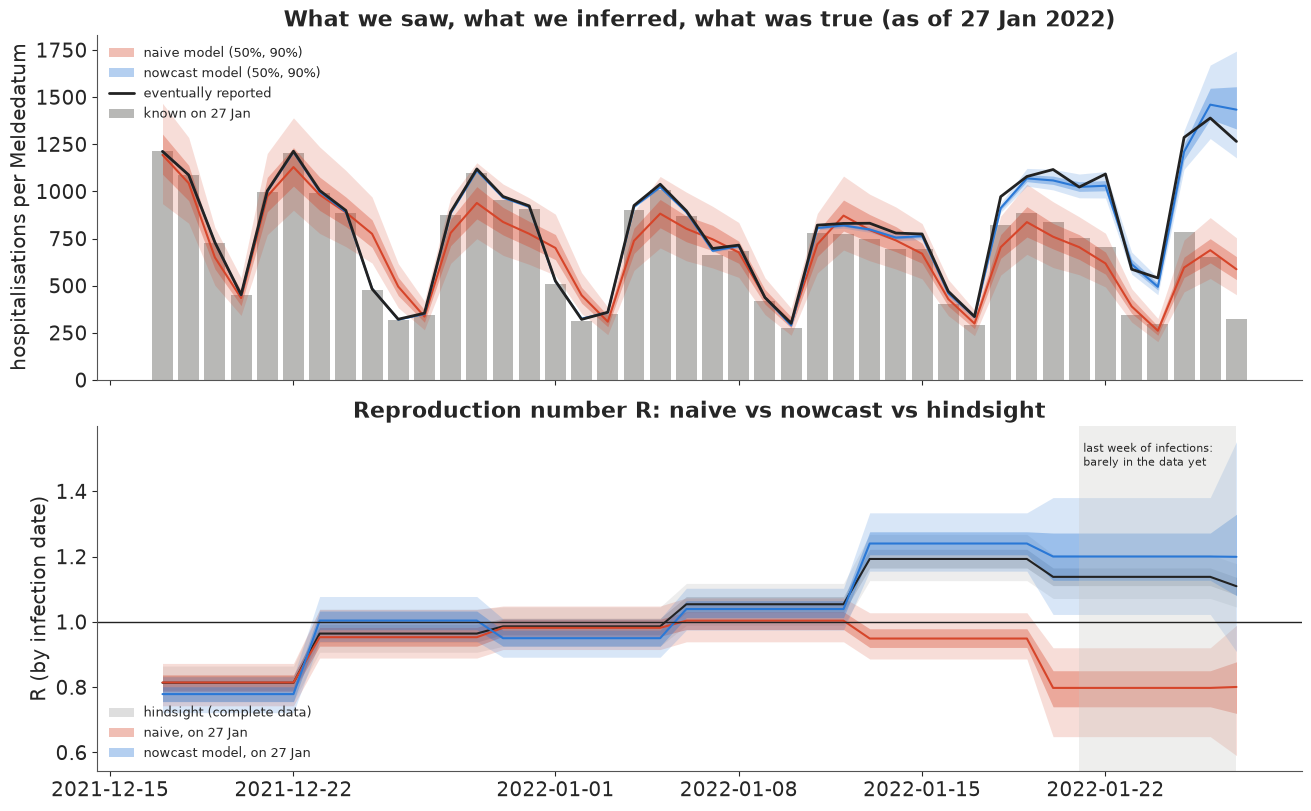

In [13]:
def band(ax, x, draws, color, label=None, probs=(0.05, 0.25, 0.75, 0.95), alpha=(0.18, 0.35)):
    q = np.nanquantile(draws, probs, axis=0)
    ax.fill_between(x, q[0], q[3], color=color, alpha=alpha[0], lw=0)
    ax.fill_between(x, q[1], q[2], color=color, alpha=alpha[1], lw=0, label=label)
    ax.plot(x, np.nanmedian(draws, axis=0), color=color, lw=1.5)


SHOW = d_main >= ASOF - pd.Timedelta(days=41)
naive_pp = naive_draws(naive_idata)
inf_dates = pd.date_range(START - pd.Timedelta(days=KMAX), periods=len(d_main) + KMAX)
inf_hind = pd.date_range(START - pd.Timedelta(days=KMAX), periods=len(V_hind) + KMAX)
R_now, R_naive, R_hind = (stacked(i, "R") for i in (nowcast_idata, naive_idata, hind_idata))

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax = axes[0]
ax.bar(d_main[SHOW], seen_main[SHOW], color=KNOWN, alpha=0.6, width=0.8, label="known on 27 Jan")
band(ax, d_main[SHOW], naive_pp[:, SHOW], NAIVE, "naive model (50%, 90%)")
band(ax, d_main[SHOW], main_final[:, SHOW], NOWC, "nowcast model (50%, 90%)")
ax.plot(d_main[SHOW], truth_main[SHOW], color=TRUTH, lw=2, label="eventually reported")
ax.set(ylabel="hospitalisations per Meldedatum", title="What we saw, what we inferred, what was true (as of 27 Jan 2022)")
ax.legend(fontsize=9, loc="upper left")
ax = axes[1]
SHOW_I = (inf_dates >= d_main[SHOW][0]) & (inf_dates <= ASOF)
SHOW_H = (inf_hind >= d_main[SHOW][0]) & (inf_hind <= ASOF)
band(ax, inf_hind[SHOW_H], R_hind[:, SHOW_H], TRUTH, "hindsight (complete data)", alpha=(0.08, 0.15))
band(ax, inf_dates[SHOW_I], R_naive[:, SHOW_I], NAIVE, "naive, on 27 Jan")
band(ax, inf_dates[SHOW_I], R_now[:, SHOW_I], NOWC, "nowcast model, on 27 Jan")
ax.axhline(1, color=TRUTH, lw=1)
ax.axvspan(ASOF - pd.Timedelta(days=6), ASOF, color=GREY, alpha=0.3, lw=0)
ax.text(ASOF - pd.Timedelta(days=6), ax.get_ylim()[1] * 0.97, " last week of infections:\n barely in the data yet",
        fontsize=8, va="top")
ax.set(ylabel="R (by infection date)", title="Reproduction number R: naive vs nowcast vs hindsight")
ax.legend(fontsize=9, loc="lower left");

In [14]:
NOW_LAG = 7  # "current" R: infections one week before the as-of date (the latest that are mostly in the data)


def at(dates_idx, day):
    return int(np.nonzero(dates_idx == day)[0][0])


i_now, i_now_h = at(inf_dates, ASOF - pd.Timedelta(days=NOW_LAG)), at(inf_hind, ASOF - pd.Timedelta(days=NOW_LAG))
for name, Rd, i in [("naive", R_naive, i_now), ("nowcast", R_now, i_now), ("hindsight", R_hind, i_now_h)]:
    q = np.quantile(Rd[:, i], [0.05, 0.5, 0.95])
    print(f"{name:>9}: R on {(ASOF - pd.Timedelta(days=NOW_LAG)).date()} = {q[1]:.2f} (90% {q[0]:.2f}-{q[2]:.2f}), "
          f"P(R > 1) = {np.mean(Rd[:, i] > 1):.2f}")

    naive: R on 2022-01-20 = 0.80 (90% 0.65-0.92), P(R > 1) = 0.00
  nowcast: R on 2022-01-20 = 1.20 (90% 1.02-1.38), P(R > 1) = 0.96
hindsight: R on 2022-01-20 = 1.14 (90% 1.07-1.21), P(R > 1) = 1.00


On 27 January the national data showed about 3,900 hospitalisations for the past seven days;
about 7,200 were eventually reported. The nowcast said about 7,300 (90%: 6,700 to 7,900), with the
truth near its middle. In the top panel the naive model takes the grey bars at face value, and
the only way a renewal model can "explain" the drop at the end is falling transmission: its $R$
for infections around 20 January is about 0.8, and it is *certain* the epidemic is shrinking
($P(R > 1) \approx 0$). The nowcast model says $R \approx 1.2$ with $P(R > 1) \approx 0.96$;
hindsight says about 1.14, growing beyond doubt. The two real-time fits part ways about two
weeks before the as-of date, which is how far back the fog reaches once the infection-to-report
delay is added to the reporting delay.

Note the grey zone. Infections in the last week before 27 January have barely reached the data
yet (about six days from infection to a reported case, then the reporting delay), so $R$ there
is mostly the random walk carrying the last informed week forward. That is why every
"current" $R$ in this notebook is for infections a week before the as-of date.

> **In plain words:** Taken at face value, the numbers on 27 January 2022 said each infection was
> leading to fewer than one new infection: the wave was ending. Once we allow for the reports
> still to come, the same numbers say it was growing, with each infection leading to about 1.2 new
> ones - which is what the complete data showed weeks later.

## 6 · Does the model describe the triangle? Posterior predictive checks

Two checks aimed at the parts that matter for a nowcast. **(a)** For every Meldedatum with
all 40 delays known, the share of its final count that arrived by day 0, 3, 7 and 14,
against the same shares in replicated triangles. **(b)** The *partially* known rows - the
ones the nowcast is about: the total reported so far for each of the last 40 days against
its posterior predictive, as a PIT (the share of replications below the observed value; it
should look uniform).

(a) share of observed delay shares inside the replicated 90% band: 0.80; (b) PIT below 0.1: 0.15, above 0.9: 0.10


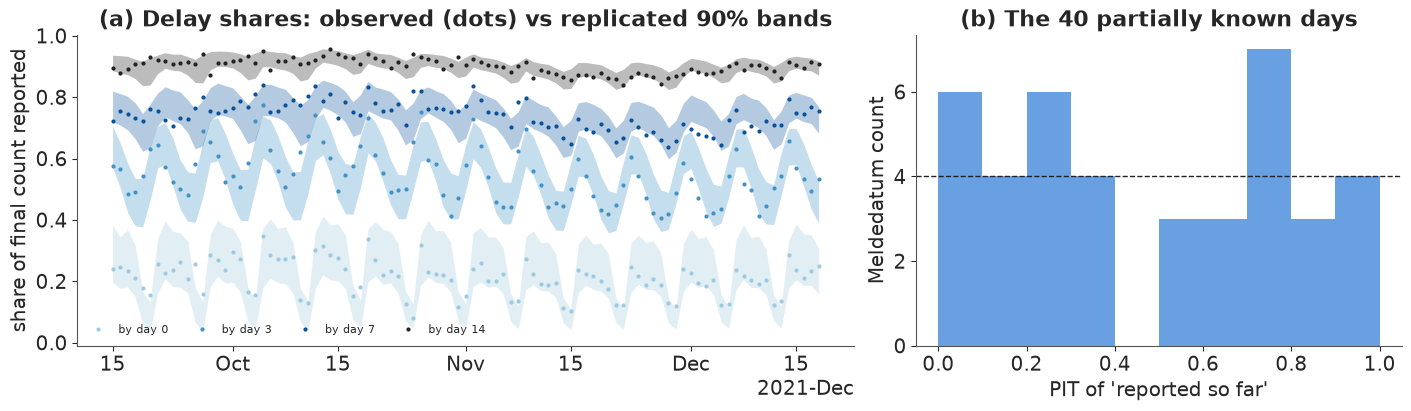

In [15]:
T_main = len(V_main)
rep_share = np.cumsum(main_sim, axis=2) / np.maximum(main_sim.sum(axis=2, keepdims=True), 1)
obs_share = np.cumsum(V_main, axis=1) / V_main.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
rows = np.nonzero(known_main.all(axis=1))[0]
for dd, col in zip([0, 3, 7, 14], ["#9ecae1", "#4292c6", "#08519c", TRUTH]):
    lo_, hi_ = np.quantile(rep_share[:, rows, dd], [0.05, 0.95], axis=0)
    ax.fill_between(d_main[rows], lo_, hi_, color=col, alpha=0.3, lw=0)
    ax.plot(d_main[rows], obs_share[rows, dd], ".", color=col, ms=4, label=f"by day {dd}")
ax.set(ylabel="share of final count reported", title="(a) Delay shares: observed (dots) vs replicated 90% bands")
date_axis(ax)
ax.legend(fontsize=8, ncol=4, loc="lower left")
partial = np.nonzero(~known_main.all(axis=1))[0]
rep_partial = (main_sim[:, partial] * known_main[partial][None]).sum(axis=2)
pit = (rep_partial < seen_main[partial]).mean(axis=0) + 0.5 * (rep_partial == seen_main[partial]).mean(axis=0)
ax = axes[1]
ax.hist(pit, bins=np.linspace(0, 1, 11), color=NOWC, alpha=0.7)
ax.axhline(len(pit) / 10, color=TRUTH, lw=1, ls="--")
ax.set(xlabel="PIT of 'reported so far'", ylabel="Meldedatum count", title=f"(b) The {len(pit)} partially known days")
cover = np.mean((obs_share[rows][:, [0, 3, 7, 14]] >= np.quantile(rep_share[:, rows][:, :, [0, 3, 7, 14]], 0.05, axis=0))
                & (obs_share[rows][:, [0, 3, 7, 14]] <= np.quantile(rep_share[:, rows][:, :, [0, 3, 7, 14]], 0.95, axis=0)))
print(f"(a) share of observed delay shares inside the replicated 90% band: {cover:.2f}; "
      f"(b) PIT below 0.1: {np.mean(pit < 0.1):.2f}, above 0.9: {np.mean(pit > 0.9):.2f}")

(a) The weekly zig-zag of the delay shares - a Friday's cases wait over the weekend - is
reproduced, but only about 80% of the observed shares fall inside the replicated 90% bands:
the reporting speed varies more from day to day than the model allows (day-3 shares below the
band in late October, day-7 shares in mid-December). (b) The PIT of the partially known days is
roughly uniform, with a mild excess below 0.1. Both checks point the same way: the model is
somewhat too sure about how fast reports will arrive. The backtest will show what that costs.

## 7 · The generation interval: R depends on it, the growth rate does not

The generation interval was fixed. How much does that matter? Refit with a mean of 3 and of
6 days (same shape). The data constrain the *infection curve*, so its **growth rate**
$r_t = \tfrac17\log(I_t/I_{t-7})$ should barely move, while $R_t$, which converts growth into
"people infected per person", depends on the interval: for exponential growth at rate $r$,
$R = 1 / \sum_s g_s e^{-rs}$ (Wallinga & Lipsitch 2007, *Proceedings of the Royal Society B*). A
longer interval turns the same growth into a larger $R$. Note what cannot change: $R > 1$
exactly when $r > 0$, whatever the interval, so the answer to "is it growing?" is robust.

generation interval mean 3 d: divergences 1, tuning steps 800, median tree depth 4; sigma_R: max r_hat 1.000, min ESS 1494; log_R_week: max r_hat 1.005, min ESS 557; lam: max r_hat 1.010, min ESS 2792


generation interval mean 6 d: divergences 2, tuning steps 800, median tree depth 4; sigma_R: max r_hat 1.002, min ESS 1765; log_R_week: max r_hat 1.009, min ESS 441; lam: max r_hat 1.008, min ESS 2563
GI mean 3: on 2022-01-20 R median 1.13, growth 4.5%/day, P(growing) 0.95
GI mean 4.5: on 2022-01-20 R median 1.20, growth 3.9%/day, P(growing) 0.96
GI mean 6: on 2022-01-20 R median 1.27, growth 3.4%/day, P(growing) 0.98


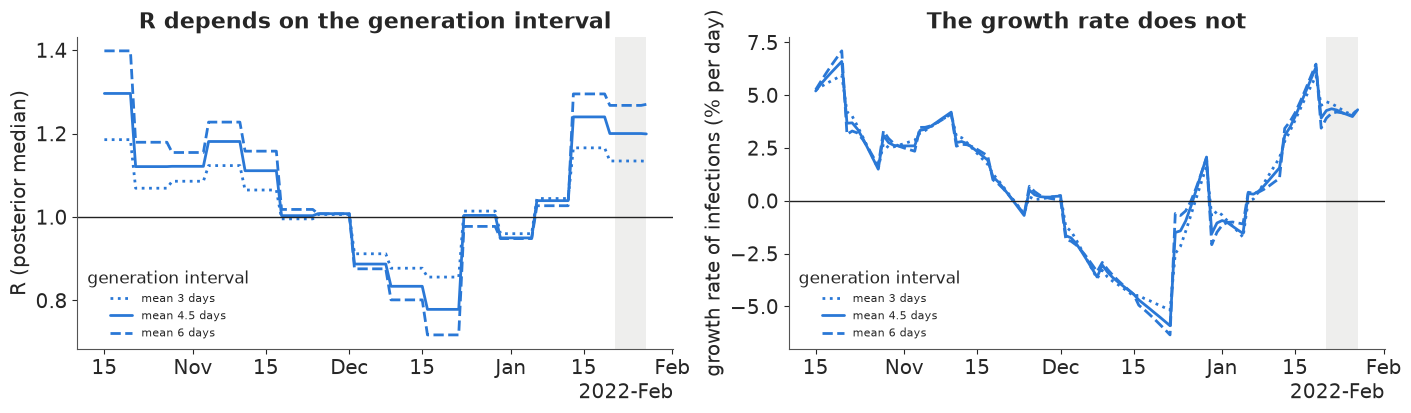

In [16]:
def growth_rate(idata, n=None):
    I = stacked(idata, "infections", n)
    return np.log(I[:, 7:] / I[:, :-7]) / 7  # aligned with inf_dates[7:]


gi_fits = {GI_MEAN: nowcast_idata}
for gm in [3.0, 6.0]:
    gi_fits[gm] = fit(build_model(V_main, known_main, START, gi_mean=gm), draws=500)
    diagnose(gi_fits[gm], f"generation interval mean {gm:g} d")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
SHOW_G = inf_dates[7:] >= pd.Timestamp("2021-10-15")
for (gm, idt), ls in zip(sorted(gi_fits.items()), [":", "-", "--"]):
    Rg, rg = stacked(idt, "R"), growth_rate(idt)
    axes[0].plot(inf_dates[7:][SHOW_G], np.median(Rg[:, 7:][:, SHOW_G], axis=0), ls, color=NOWC, lw=2,
                 label=f"mean {gm:g} days")
    axes[1].plot(inf_dates[7:][SHOW_G], np.median(rg[:, SHOW_G], axis=0) * 100, ls, color=NOWC, lw=2,
                 label=f"mean {gm:g} days")
    print(f"GI mean {gm:g}: on {(ASOF - pd.Timedelta(days=NOW_LAG)).date()} R median {np.median(Rg[:, i_now]):.2f}, "
          f"growth {np.median(rg[:, i_now - 7]) * 100:.1f}%/day, P(growing) {np.mean(Rg[:, i_now] > 1):.2f}")
axes[0].axhline(1, color=TRUTH, lw=1)
axes[0].set(ylabel="R (posterior median)", title="R depends on the generation interval")
axes[1].axhline(0, color=TRUTH, lw=1)
axes[1].set(ylabel="growth rate of infections (% per day)", title="The growth rate does not")
for ax in axes:
    ax.axvspan(ASOF - pd.Timedelta(days=6), ASOF, color=GREY, alpha=0.3, lw=0)
    ax.legend(title="generation interval", fontsize=8)
    date_axis(ax)

The $R$ curves fan out: with a 6-day interval $R$ is about 1.4 in early October, with a
3-day interval about 1.2; in the December decline the order reverses (a longer interval gives
a *lower* $R$ when the epidemic shrinks), exactly as the Wallinga-Lipsitch relation predicts.
The growth-rate curves lie almost on top of each other across the window. At the edge, where
the data say least, even the growth rate differs somewhat (about 3.4 to 4.5% per day for 20
January), because the random walk is on $\log R$, so the prior for the unseen days depends on
the interval. The chance that infections were growing on 20 January is 0.95 to 0.98 under
all three. (The 6-day interval is cut at 14 days like the others, so its effective mean is a
little under 6.)

> **In plain words:** "How many people does each infected person infect?" depends on an assumption
> about how quickly one infection leads to the next. "Is it growing, and how fast?" hardly
> does. For the decision of the day, report the growth or the doubling time.

## 8 · A real backtest: five dates, checked against what happened

One date is an anecdote. We repeat the whole exercise as it would have been done on five
Thursdays three weeks apart, from the rise of the Delta wave (4 November) to Omicron (27
January), each time using only the triangle known that day. For each date we nowcast the
**7-day hospitalisation count** (the headline number in Germany then) for each of the last
14 days, and score it against the final count:

- **coverage**: how often the truth falls inside the 50% and 90% intervals (should be about
  50% and 90%);
- the **continuous ranked probability score** (CRPS), a proper score in units of
  hospitalisations: the average distance between forecast draws and the truth, minus half
  the average distance between two draws. For a single number (the "last reported" baseline,
  which is what the dashboard showed) it is just the absolute error. Lower is better.

In [17]:
def crps(draws, y):
    """Sample CRPS per column: E|X - y| - 0.5 E|X - X'| (sorted-sample formula)."""
    x = np.sort(draws, axis=0)
    n = len(x)
    w = (2 * np.arange(1, n + 1) - n - 1)[:, None]
    return np.mean(np.abs(x - y[None]), axis=0) - np.sum(w * x, axis=0) / n**2


VINTAGES = pd.date_range("2021-11-04", ASOF, freq="3W-THU")
backtest, realtime = [], []
for a in VINTAGES:
    V_a, known_a = triangle_as_of(a)
    idt = nowcast_idata if a == ASOF else fit(build_model(V_a, known_a, START), target_accept=0.95)
    if a != ASOF:
        diagnose(idt, f"vintage {a.date()}")
    fin_draws, _ = nowcast_draws(idt, V_a, known_a, START)
    f7, s7 = roll7(fin_draws)[:, -14:], roll7((V_a * known_a).sum(axis=1))[-14:]
    y7 = roll7(FINAL.loc[START:a].to_numpy())[-14:]
    q = np.quantile(f7, [0.05, 0.25, 0.75, 0.95], axis=0)
    for h in range(14):
        backtest.append({"as_of": a.date(), "days_back": 13 - h, "truth": y7[h], "last_reported": s7[h],
                         "median": np.median(f7[:, h]), "lo90": q[0, h], "lo50": q[1, h], "hi50": q[2, h],
                         "hi90": q[3, h], "in50": q[1, h] <= y7[h] <= q[2, h],
                         "in90": q[0, h] <= y7[h] <= q[3, h], "crps_model": crps(f7[:, [h]], y7[[h]])[0],
                         "crps_naive": abs(s7[h] - y7[h])})
    R_a = stacked(idt, "R")
    j = at(pd.date_range(START - pd.Timedelta(days=KMAX), periods=len(V_a) + KMAX), a - pd.Timedelta(days=NOW_LAG))
    realtime.append({"as_of": a, "p_growing": float(np.mean(R_a[:, j] > 1)),
                     "p_growing_hindsight": float(np.mean(R_hind[:, at(inf_hind, a - pd.Timedelta(days=NOW_LAG))] > 1)),
                     "R_q": np.quantile(R_a[:, j], [0.05, 0.5, 0.95]),
                     "seen7": s7[-1], "truth7": y7[-1],
                     "known_share_model": s7[[0, -1]] / np.median(f7[:, [0, -1]], axis=0),
                     "known_share_actual": s7[[0, -1]] / y7[[0, -1]], "nowcast7_q": np.quantile(f7[:, -1], [0.05, 0.25, 0.5, 0.75, 0.95]),
                     "known": (V_a * known_a).sum(axis=1)[-28:], "final_draws_7": f7[:, -1]})
    if a != ASOF:
        del idt
bt = pd.DataFrame(backtest)
by_date = bt.groupby("as_of").agg(coverage_50=("in50", "mean"), coverage_90=("in90", "mean"),
                                  crps_model=("crps_model", "mean"), crps_last_reported=("crps_naive", "mean"))
by_date.loc["all"] = [bt.in50.mean(), bt.in90.mean(), bt.crps_model.mean(), bt.crps_naive.mean()]
for col, key, h in [("known 13 d back: model", "known_share_model", 0), ("known 13 d back: actual", "known_share_actual", 0),
                    ("known last week: model", "known_share_model", 1), ("known last week: actual", "known_share_actual", 1)]:
    by_date[col] = [rt[key][h] for rt in realtime] + [np.nan]
by_date.round(2)

vintage 2021-11-04: divergences 0, tuning steps 800, median tree depth 4; sigma_R: max r_hat 1.001, min ESS 1487; log_R_week: max r_hat 1.003, min ESS 1556; lam: max r_hat 1.003, min ESS 2030


vintage 2021-11-25: divergences 0, tuning steps 800, median tree depth 4; sigma_R: max r_hat 1.000, min ESS 1583; log_R_week: max r_hat 1.002, min ESS 1345; lam: max r_hat 1.006, min ESS 2344


vintage 2021-12-16: divergences 0, tuning steps 800, median tree depth 4; sigma_R: max r_hat 1.001, min ESS 1905; log_R_week: max r_hat 1.003, min ESS 1318; lam: max r_hat 1.003, min ESS 3668


vintage 2022-01-06: divergences 0, tuning steps 800, median tree depth 4; sigma_R: max r_hat 1.001, min ESS 2589; log_R_week: max r_hat 1.003, min ESS 725; lam: max r_hat 1.006, min ESS 3562


,coverage_50,coverage_90,crps_model,crps_last_reported,known 13 d back: model,known 13 d back: actual,known last week: model,known last week: actual
as_of,,,,,,,,
2021-11-04,0.29,1.00,125.98,1126.50,0.93,0.93,0.48,0.51
2021-11-25,0.86,1.00,84.11,2503.93,0.91,0.90,0.45,0.46
2021-12-16,0.00,0.00,682.61,2295.00,0.86,0.89,0.42,0.51
2022-01-06,0.00,0.29,189.63,1060.64,0.91,0.92,0.47,0.54
2022-01-27,0.14,0.50,104.16,1268.64,0.95,0.93,0.53,0.54
all,0.26,0.56,237.30,1650.94,NaN,NaN,NaN,NaN


days_back       0       1       2       3       4       5       6       7       8      9      10     11     12     13
crps_model   498.0   436.0   375.0   315.0   289.0   250.0   200.0   180.0   154.0  149.0  134.0  126.0  116.0  100.0
crps_naive  3683.0  2996.0  2494.0  2210.0  2056.0  1877.0  1597.0  1357.0  1124.0  918.0  797.0  745.0  670.0  588.0
reporting-speed drift beta by Meldedatum week (27 Jan fit, logit scale):
15 Sep    0.00
22 Sep    0.05
29 Sep    0.09
06 Oct    0.07
13 Oct    0.14
20 Oct    0.06
27 Oct    0.06
03 Nov   -0.01
10 Nov   -0.09
17 Nov   -0.10
24 Nov   -0.09
01 Dec   -0.03
08 Dec   -0.01
15 Dec    0.01
22 Dec    0.05
29 Dec    0.05
05 Jan    0.17
12 Jan    0.20
19 Jan    0.14
26 Jan    0.11


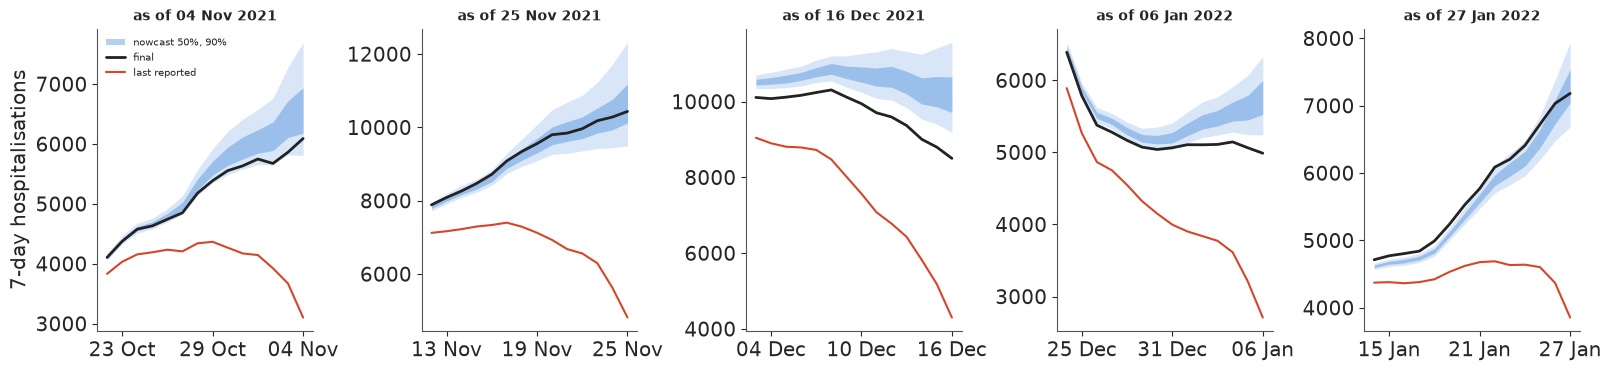

In [18]:
fig, axes = plt.subplots(1, len(VINTAGES), figsize=(16, 3.6), sharey=False)
for ax, a in zip(axes, VINTAGES):
    b = bt[bt.as_of == a.date()]
    x = pd.date_range(end=a, periods=14)
    ax.fill_between(x, b.lo90, b.hi90, color=NOWC, alpha=0.18, lw=0)
    ax.fill_between(x, b.lo50, b.hi50, color=NOWC, alpha=0.35, lw=0, label="nowcast 50%, 90%")
    ax.plot(x, b.truth, color=TRUTH, lw=2, label="final")
    ax.plot(x, b.last_reported, color=NAIVE, lw=1.5, label="last reported")
    ax.set_title(f"as of {a:%d %b %Y}", fontsize=10)
    ax.set_xticks(x[[1, 7, 13]], [f"{d_:%d %b}" for d_ in x[[1, 7, 13]]])
axes[0].set_ylabel("7-day hospitalisations")
axes[0].legend(fontsize=7)
print(bt.groupby("days_back")[["crps_model", "crps_naive"]].mean().round(0).T.to_string())
beta_week = pd.Series(np.median(stacked(nowcast_idata, "beta"), axis=0),
                      index=[f"{d_:%d %b}" for d_ in d_main[::7]])
print("reporting-speed drift beta by Meldedatum week (27 Jan fit, logit scale):\n" + beta_week.round(2).to_string())

The nowcast is far more accurate than reading off the latest numbers: its mean CRPS is about
240 hospitalisations against about 1,650, roughly seven times smaller, and it wins at every
horizon (on the most recent day about 500 against 3,700; even 13 days back, when about 90% of
the week is in, about 100 against 600). But its intervals are **too narrow**: the 50% intervals
contain the final count about a quarter of the time and the 90% intervals a little over half.
The misses are concentrated, and the last four columns say why. On 16 December the model
believed that 42% of the last week's hospitalisations had been reported; in fact 51% had.
Reporting had slowed from October to late November (the fitted drift $\beta$ printed above
falls from about +0.1 to about -0.1 on the logit scale) and was speeding up again through
December (back to about +0.2 by January). A random walk extrapolates the recent past, so on
16 December the model still expected the slow reporting of late November, and the nowcast was
too high on all 14 days. The 6 January
vintage has the same problem in milder form (47% believed, 54% actual). On 4 and 25 November
the 90% intervals covered all 14 days.

Two assumptions make the intervals optimistic: that the coming weeks' delays resemble the
recent past, and that the cells are independent given the expected counts, so that the
day-to-day wobbles in reporting speed seen in section 6 average out in a 7-day sum. In
prototypes (not shown) we added a random walk over the *reporting* week, a per-Meldedatum
delay effect, a delay shape that tilts week by week, and a shorter training window; none
restored nominal coverage on these five dates, and some doubled or tripled the run time. Five
dates are few and the 14 horizons within a date are strongly correlated, so the coverage
figures are themselves very uncertain - but the direction is clear.

> **In plain words:** Allowing for late reports made the figures about seven times more
> accurate than the raw numbers, on every date we checked. But the model's "likely ranges" were
> too narrow - it was caught out most in December, when reports started arriving faster than
> before - so read them as optimistic.

## 9 · Explaining it to everyone

The audience now is a journalist, a council member, a hospital manager. They do not want
$R_t$; they want to know *whether it is getting worse*, *how much we are not seeing yet*, and
*what next week looks like*. Four displays, all computed from the fits above.

### 9.1 A traffic light for "is it growing?", and what it said at the time

Top: for each day of infections from October to January, the chance - according to the
hindsight fit - that infections were growing that day, as a traffic-light strip. Below: five
dials showing what the nowcast model said *on the day* at each backtest date (the needle), with
the hindsight answer as a black tick for comparison.

04 Nov 2021: said then P(growing) = 0.71 (R 1.06, 90% 0.86-1.26); hindsight P(growing) = 1.00


25 Nov 2021: said then P(growing) = 0.70 (R 1.05, 90% 0.89-1.21); hindsight P(growing) = 0.61
16 Dec 2021: said then P(growing) = 0.22 (R 0.94, 90% 0.81-1.07); hindsight P(growing) = 0.00
06 Jan 2022: said then P(growing) = 0.91 (R 1.14, 90% 0.97-1.35); hindsight P(growing) = 0.35
27 Jan 2022: said then P(growing) = 0.96 (R 1.20, 90% 1.02-1.38); hindsight P(growing) = 1.00


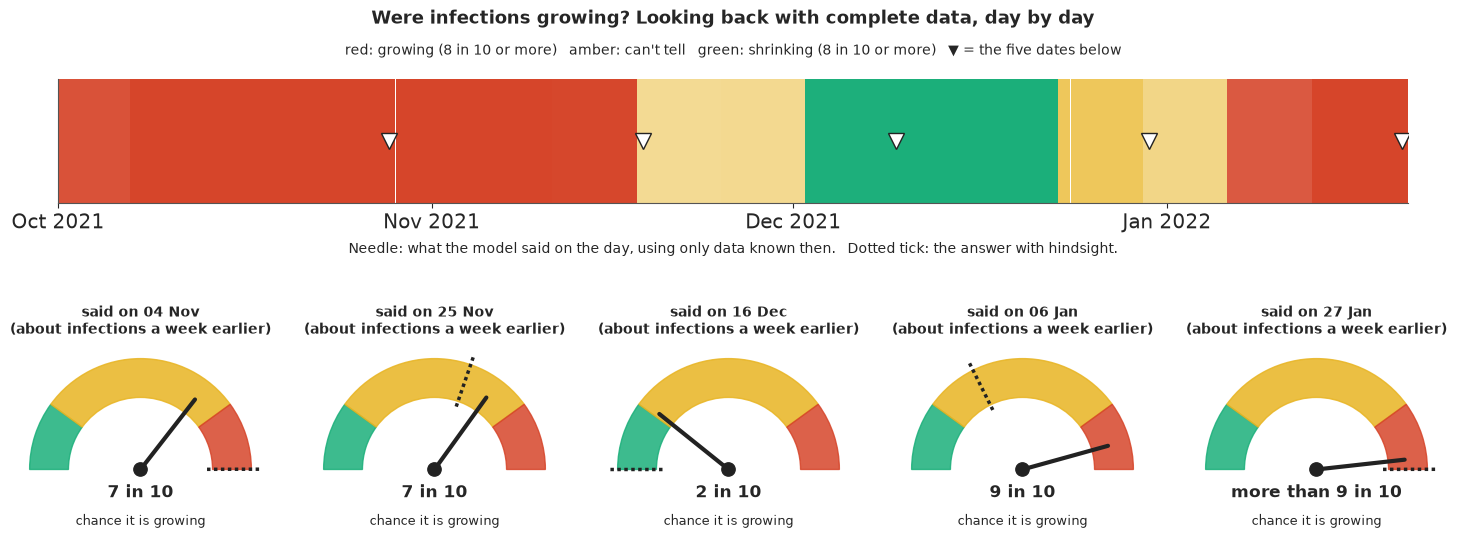

In [19]:
def light_colour(p):
    return GROW if p >= 0.8 else SHRINK if p <= 0.2 else FLAT


def dial(ax, p, p_ref, title):
    for lo_, hi_, c in [(0, 0.2, SHRINK), (0.2, 0.8, FLAT), (0.8, 1.0, GROW)]:
        ax.add_patch(Wedge((0, 0), 1, 180 - hi_ * 180, 180 - lo_ * 180, width=0.35, color=c, alpha=0.85))
    ang = np.pi * (1 - p)
    ax.plot([0, 0.8 * np.cos(ang)], [0, 0.8 * np.sin(ang)], color=TRUTH, lw=3, solid_capstyle="round")
    ax.add_patch(plt.Circle((0, 0), 0.06, color=TRUTH))
    ang_r = np.pi * (1 - p_ref)
    ax.plot([0.6 * np.cos(ang_r), 1.08 * np.cos(ang_r)], [0.6 * np.sin(ang_r), 1.08 * np.sin(ang_r)],
            color=TRUTH, lw=2.5, ls=(0, (1, 1)))
    ax.text(0, -0.25, in_ten(p), ha="center", fontsize=12, weight="bold")
    ax.text(0, -0.5, "chance it is growing", ha="center", fontsize=9)
    ax.set(xlim=(-1.15, 1.15), ylim=(-0.6, 1.15), aspect="equal", xticks=[], yticks=[])
    ax.set_title(title, fontsize=10)
    for s in ax.spines.values():
        s.set_visible(False)


strip_days = (inf_hind >= pd.Timestamp("2021-10-01")) & (inf_hind <= ASOF - pd.Timedelta(days=NOW_LAG))
p_strip = np.mean(R_hind[:, strip_days] > 1, axis=0)
fig = plt.figure(figsize=(15, 6.2), layout="none")
ax = fig.add_axes([0.05, 0.66, 0.9, 0.2])
for x_, p_ in zip(inf_hind[strip_days], p_strip):
    ax.add_patch(Rectangle((x_.toordinal(), 0), 1, 1, facecolor=light_colour(p_), lw=0,
                           alpha=0.35 + 0.65 * abs(p_ - 0.5) * 2))
ax.set(xlim=(inf_hind[strip_days][0].toordinal(), inf_hind[strip_days][-1].toordinal() + 1), ylim=(0, 1), yticks=[])
ticks = pd.date_range("2021-10-01", ASOF, freq="MS")
ax.set_xticks([t.toordinal() for t in ticks], [f"{t:%b %Y}" for t in ticks])
for rt in realtime:
    ax.plot((rt["as_of"] - pd.Timedelta(days=NOW_LAG)).toordinal() + 0.5, 0.5, "v", color="white", mec=TRUTH, ms=11)
fig.text(0.5, 0.95, "Were infections growing? Looking back with complete data, day by day", ha="center",
         fontsize=13, weight="bold")
fig.text(0.5, 0.9, "red: growing (8 in 10 or more)   amber: can't tell   green: shrinking (8 in 10 or more)   "
         "▼ = the five dates below", ha="center", fontsize=10)
for k, rt in enumerate(realtime):
    axd = fig.add_axes([0.02 + k * 0.196, 0.03, 0.17, 0.5])
    dial(axd, rt["p_growing"], rt["p_growing_hindsight"],
         f"said on {rt['as_of']:%d %b}\n(about infections a week earlier)")
fig.text(0.5, 0.58, "Needle: what the model said on the day, using only data known then.   "
         "Dotted tick: the answer with hindsight.", ha="center", fontsize=10)
for rt in realtime:
    print(f"{rt['as_of']:%d %b %Y}: said then P(growing) = {rt['p_growing']:.2f} (R {rt['R_q'][1]:.2f}, "
          f"90% {rt['R_q'][0]:.2f}-{rt['R_q'][2]:.2f}); hindsight P(growing) = {rt['p_growing_hindsight']:.2f}")

**Why it works:** a traffic light is the most familiar three-state display there is, and the
words in the dial ("7 in 10") say how sure the light is instead of pretending it is certain;
the pale cells in the strip are the days the model could not call. The dials put the real-time
answer next to the hindsight one, which is the honest way to show a forecaster's record. Here
the record is mixed. On 4 November and 16 December the model leaned the right way (7 in 10
growing; 2 in 10) where hindsight is certain; on 25 November, with the Delta wave peaking,
the model and hindsight are both unsure; on 27 January it was right. On 6 January it said 9 in
10 for growth where hindsight says about 1 in 3: the one wrong call, in the post-Christmas
weeks when reporting was speeding up (section 8) and Omicron was only beginning to take off. **What it hides:** the lights are about *infections a week earlier* (the latest the
data can speak to), and three colours throw away the size of the growth.

### 9.2 "Of 100 hospitalisations this week, how many can we see?"

An icon array for the week ending 27 January 2022: 100 squares stand for 100 hospitalisations
with a Meldedatum in that week. Dark squares were already in the data on 27 January; light
squares were certainly still to come; hatched squares are the honest uncertainty - maybe
already all there, maybe not.

share of the week seen on 27 Jan: model median 0.53 (90% 0.49-0.58); with hindsight it was 0.54


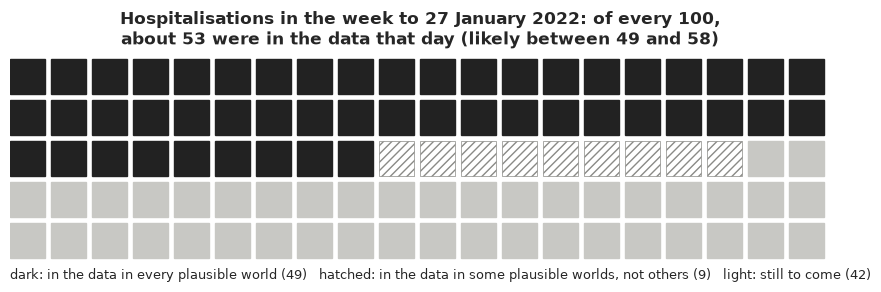

In [20]:
share_seen = roll7(seen_main)[-1] / roll7(main_final)[:, -1]
s_lo, s_med, s_hi = np.quantile(share_seen, [0.05, 0.5, 0.95])
n_seen_lo, n_seen_med, n_seen_hi = (int(round(100 * v)) for v in (s_lo, s_med, s_hi))
true_share = roll7(seen_main)[-1] / roll7(truth_main)[-1]
fig, ax = plt.subplots(figsize=(9, 5.4))
for i in range(100):
    r_, c_ = divmod(i, 20)
    if i < n_seen_lo:
        kw = dict(color=TRUTH)
    elif i < n_seen_hi:
        kw = dict(facecolor="white", edgecolor=KNOWN, hatch="////", lw=0.5)
    else:
        kw = dict(color=GREY)
    ax.add_patch(Rectangle((c_, 4 - r_), 0.85, 0.85, **kw))
ax.set(xlim=(0, 20), ylim=(-0.3, 5), xticks=[], yticks=[], aspect="equal")
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title(f"Hospitalisations in the week to 27 January 2022: of every 100,\n"
             f"about {n_seen_med} were in the data that day (likely between {n_seen_lo} and {n_seen_hi})", fontsize=12)
ax.text(0, -0.25, f"dark: in the data in every plausible world ({n_seen_lo})   hatched: in the data in some plausible "
        f"worlds, not others ({n_seen_hi - n_seen_lo})   light: still to come ({100 - n_seen_hi})", fontsize=9, va="top")
print(f"share of the week seen on 27 Jan: model median {s_med:.2f} (90% {s_lo:.2f}-{s_hi:.2f}); "
      f"with hindsight it was {true_share:.2f}")

**Why it works:** "of 100, about half" is understood by everyone, and the hatched squares make the
uncertainty a visible, countable thing - about ten squares we are not sure about - rather than an
interval. The truth, known weeks later, was 54 of 100: inside the hatched range. **What it
hides:** the known count is exact; what is uncertain is how many are still missing. The
array turns that into an uncertain share, which is the right question for a reader but not
the model's native quantity.

### 9.3 Watching the fog lift (animation)

Press play. We stand on 27 January and look at the last three weeks. The blue brackets are the
nowcast made that day (the likely range for each day's final count, 9 times out of 10, with a
tick at the best guess). Then time moves on: each frame is one day later, and the grey bars
are *the real data as they were known on that day*. The bars grow into the brackets.

In [21]:
N_BACK, N_FRAMES = 21, 36
fog_dates = d_main[-N_BACK:]
fog_q = np.quantile(main_final[:, -N_BACK:], [0.05, 0.5, 0.95], axis=0)
V_future = de.loc[fog_dates[0]:fog_dates[-1], DELAY_COLS].to_numpy(float)
frames = []
for k in range(N_FRAMES):
    known_k = (np.arange(N_BACK)[:, None] + np.arange(D + 1)[None, :]) <= N_BACK - 1 + k
    frames.append((V_future * known_k).sum(axis=1))
week_share = [f[-7:].sum() / V_future[-7:].sum() for f in frames]

fig, ax = plt.subplots(figsize=(9, 4.4), dpi=72)
x = np.arange(N_BACK)
bars = ax.bar(x, frames[0], color=GREY, width=0.7)
for i in range(N_BACK):
    ax.plot([i - 0.42, i + 0.42, np.nan, i - 0.42, i + 0.42], [fog_q[0, i]] * 2 + [np.nan] + [fog_q[2, i]] * 2,
            color=NOWC, lw=1.5, zorder=3)
    ax.plot([i, i], [fog_q[0, i], fog_q[2, i]], color=NOWC, lw=1, zorder=3)
    ax.plot([i - 0.3, i + 0.3], [fog_q[1, i]] * 2, color=NOWC, lw=3, zorder=3)
ax.set_xticks(x[::3], [f"{d_:%d %b}" for d_ in fog_dates[::3]])
ax.set(ylim=(0, fog_q[2].max() * 1.1), ylabel="hospitalisations per day", xlabel="Meldedatum")
title = ax.set_title("")
plt.close(fig)


def update(k):
    for b_, h_ in zip(bars, frames[k]):
        b_.set_height(h_)
    when = ASOF + pd.Timedelta(days=k)
    title.set_text(f"{when:%a %d %b}: {week_share[k] * 100:.0f} in 100 of the week to 27 Jan are in the data")
    return bars


anim = animation.FuncAnimation(fig, update, frames=N_FRAMES, interval=350, blit=False)
inside = np.mean((frames[-1] >= fog_q[0]) & (frames[-1] <= fog_q[2]))
print(f"after {N_FRAMES - 1} days, {inside:.0%} of the {N_BACK} daily counts are inside the nowcast's 90% range; "
      f"share of the week in the data: day 0 {week_share[0]:.2f}, day 7 {week_share[7]:.2f}, day 35 {week_share[-1]:.2f}")
HTML(anim.to_jshtml(default_mode="once"))

after 35 days, 71% of the 21 daily counts are inside the nowcast's 90% range; share of the week in the data: day 0 0.54, day 7 0.81, day 35 0.99


**Why it works:** it shows the *process*: the fog is not a mistake in the data but reports
that have not arrived yet, and the viewer watches them arrive and settle inside (or outside) the
brackets drawn on the first day. It also answers "how long until we know?" (the title counts
it). Of the 21 days, 15 end inside their 90% bracket, a little below the nominal rate - the
backtest below quantifies this. **What it hides:** only one as-of date, and the
animation cannot be printed; section 5's top panel is its static partner.

### 9.4 Next week, as 20 equally likely answers

The renewal model can also look forward: continue the infection curve for a week (letting $R$
keep drifting as its random walk allows) and push it through the delays. A quantile dotplot
shows the forecast of total hospitalisations with a Meldedatum in the week 28 January - 3
February as 20 dots, each an equally likely answer; the black line is what was eventually
reported. Beside it, the same model's answer to "how fast is it growing?" in the
units people use: doubling time.

In [22]:
def forecast_next_week(idata, V, start, H=7, n=1000, seed=RANDOM_SEED):
    """Final hospitalisations for the H Meldedatum days after the data, by continuing the renewal process."""
    fr = np.random.default_rng(seed)
    T = len(V)
    I = stacked(idata, "infections", n)
    logR = stacked(idata, "log_R_week", n)
    sig = stacked(idata, "sigma_R", n)
    dow = stacked(idata, "dow", n)
    phi = 1 / stacked(idata, "inv_sqrt_phi", n) ** 2
    g = gen_interval()
    M = T + KMAX
    week_last = (M - 1) // 7
    extra_weeks = (M + H - 1) // 7 - week_last
    logR_future = logR[:, -1:] + np.cumsum(sig[:, None] * fr.normal(size=(len(I), extra_weeks)), axis=1)
    I_ext = np.concatenate([I, np.zeros((len(I), H))], axis=1)
    for h in range(H):
        wk = (M + h) // 7 - week_last
        R_h = np.exp(logR[:, -1] if wk == 0 else logR_future[:, wk - 1])
        I_ext[:, M + h] = R_h * (I_ext[:, M + h - SMAX:M + h][:, ::-1] * g[None]).sum(axis=1)
    fut = pd.date_range(start, periods=T + H)[T:]
    lam = np.stack([(I_ext[:, T + h + KMAX - np.arange(KMAX + 1)] * INF_TO_REPORT).sum(axis=1)
                    for h in range(H)], axis=1) * np.exp(dow[:, fut.dayofweek])
    # final count per day = sum of 41 negative-binomial cells; simulate them with the latest delay pattern
    p_last = np.exp(delay_log_prob(idata, T, start, n)[:, -1])  # last reference week's delay distribution
    cells = lam[:, :, None] * p_last[:, None, :]
    r = np.broadcast_to(phi[:, None, None], cells.shape)
    return fr.negative_binomial(r, r / (r + cells)).sum(axis=2), fut


next_draws, next_dates = forecast_next_week(nowcast_idata, V_main, START)
next_week = next_draws.sum(axis=1)
next_truth = FINAL.loc[next_dates].sum()
this_week_truth = roll7(truth_main)[-1]
rg_main = growth_rate(nowcast_idata)[:, i_now - 7]
with np.errstate(divide="ignore"):
    doubling = np.log(2) / rg_main
print(f"next week (28 Jan - 3 Feb): forecast median {np.median(next_week):.0f} (90% {np.quantile(next_week, 0.05):.0f}-"
      f"{np.quantile(next_week, 0.95):.0f}); eventually reported {next_truth:.0f}; P(next week > this week's final) = "
      f"{np.mean(next_week > this_week_truth):.2f}")
print(f"growth rate on {(ASOF - pd.Timedelta(days=NOW_LAG)).date()}: median {np.median(rg_main) * 100:.1f}%/day; "
      f"doubling time median {np.median(doubling):.0f} days, 80% {np.quantile(doubling, 0.1):.0f}-{np.quantile(doubling, 0.9):.0f} "
      f"(share of draws shrinking: {np.mean(rg_main < 0):.2f})")

next week (28 Jan - 3 Feb): forecast median 10254 (90% 7159-14516); eventually reported 8483; P(next week > this week's final) = 0.95
growth rate on 2022-01-20: median 3.9%/day; doubling time median 18 days, 80% 12-31 (share of draws shrinking: 0.00)


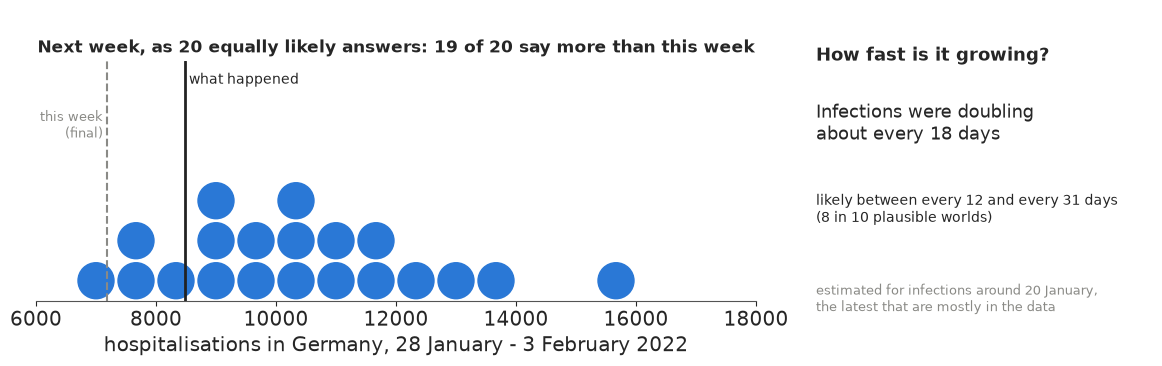

In [23]:
def quantile_dotplot(ax, samples, n_dots=20, n_bins=18, color=NOWC, xlim=None):
    q = np.quantile(samples, (np.arange(n_dots) + 0.5) / n_dots)
    lo_, hi_ = xlim
    edges = np.linspace(lo_, hi_, n_bins + 1)
    width = edges[1] - edges[0]
    cols = np.clip(np.digitize(q, edges) - 1, 0, n_bins - 1)
    heights = np.zeros(n_bins, int)
    for c in cols:
        ax.add_patch(Ellipse((edges[c] + width / 2, (heights[c] + 0.5) * width), width * 0.9, width * 0.9, color=color))
        heights[c] += 1
    ax.set(xlim=(lo_, hi_), ylim=(0, (max(heights.max(), 5) + 1) * width), yticks=[], aspect="equal")
    for s in ["left", "right", "top"]:
        ax.spines[s].set_visible(False)
    return q


fig = plt.figure(figsize=(12, 5.2), layout="none")
ax = fig.add_axes([0.05, 0.18, 0.6, 0.66])
lo_x = np.floor(min(np.quantile(next_week, 0.01), next_truth, this_week_truth) / 1000) * 1000
hi_x = np.ceil(max(np.quantile(next_week, 0.99), next_truth) / 1000) * 1000
q20 = quantile_dotplot(ax, next_week, xlim=(lo_x, hi_x))
ax.axvline(next_truth, color=TRUTH, lw=2)
ax.text(next_truth, ax.get_ylim()[1] * 0.95, " what happened", fontsize=10, va="top")
ax.axvline(this_week_truth, color=KNOWN, lw=1.5, ls="--")
ax.text(this_week_truth, ax.get_ylim()[1] * 0.8, "this week \n(final) ", fontsize=9, ha="right", va="top", color=KNOWN)
ax.set_xlabel("hospitalisations in Germany, 28 January - 3 February 2022")
ax.set_title(f"Next week, as 20 equally likely answers: {int((q20 > this_week_truth).sum())} of 20 say more than this week",
             fontsize=12)
ax2 = fig.add_axes([0.7, 0.18, 0.28, 0.66])
ax2.axis("off")
d_lo, d_med, d_hi = np.quantile(doubling, [0.1, 0.5, 0.9])
ax2.text(0, 0.85, "How fast is it growing?", fontsize=13, weight="bold")
ax2.text(0, 0.62, f"Infections were doubling\nabout every {d_med:.0f} days", fontsize=13)
ax2.text(0, 0.38, f"likely between every {d_lo:.0f} and every {d_hi:.0f} days\n(8 in 10 plausible worlds)", fontsize=10)
ax2.text(0, 0.12, f"estimated for infections around {(ASOF - pd.Timedelta(days=NOW_LAG)):%d %B},\n"
         "the latest that are mostly in the data", fontsize=9, color=KNOWN);

**Why it works:** twenty dots are twenty equally likely futures, so "19 of 20 say more than
this week" needs no statistics, and the one far-right dot shows the tail without a scary
axis. The doubling time converts a growth rate into the unit people already use. **What it
hides:** the truth (about 8,500) was well below the median forecast (about 10,300), at the
low end of the dots. A likely reason is built into the model: it assumes each infection keeps
the same chance of ending in hospital, while Omicron, which was taking over, led to hospital
less often - so hospitalisations grew more slowly than the infections behind them. A forecast is a statement about the model
as much as about the future.

### 9.5 Export for a web page

In [24]:
def r_(x, nd=3):
    x = np.asarray(x, dtype=float)
    return [None if not np.isfinite(v) else round(float(v), nd) for v in x.ravel()]


idx = rng.choice(len(next_week), 400, replace=False)
fog_window = d_main >= ASOF - pd.Timedelta(days=41)
export = {
    "id": "E38",
    "title": "Is the epidemic growing right now? Seeing through the reporting fog",
    "data": "German COVID-19 hospitalisations by Meldedatum (RKI via the COVID-19 Nowcast Hub), national, all ages; "
            "'final' = reported within 40 days",
    "model": "renewal-equation model (weekly random-walk R, generation interval mean 4.5 d) linked to a nowcast of "
             "the reporting triangle (discrete-time delay hazard with reporting-weekday and weekly drift), "
             "negative-binomial cells",
    "as_of": str(ASOF.date()),
    "fog": {"date": [str(d_.date()) for d_ in d_main[fog_window]],
            "known_on_as_of": r_(seen_main[fog_window], 0), "final": r_(truth_main[fog_window], 0),
            "nowcast_quantiles": [0.05, 0.25, 0.5, 0.75, 0.95],
            "nowcast": [r_(np.quantile(main_final[:, fog_window], q, axis=0), 0) for q in [0.05, 0.25, 0.5, 0.75, 0.95]],
            "naive_model": [r_(np.quantile(naive_pp[:, fog_window], q, axis=0), 0) for q in [0.05, 0.5, 0.95]]},
    "fog_lifting": {"days_after_as_of": list(range(N_FRAMES)), "dates": [str(d_.date()) for d_ in fog_dates],
                    "known": [r_(f, 0) for f in frames], "share_of_week_known": r_(week_share)},
    "p_growing_by_infection_date": {"date": [str(d_.date()) for d_ in inf_hind[strip_days]],
                                    "p_hindsight": r_(p_strip)},
    "realtime": [{"as_of": str(rt["as_of"].date()), "p_growing_said_then": round(rt["p_growing"], 3),
                  "p_growing_hindsight": round(rt["p_growing_hindsight"], 3), "R_q05_q50_q95": r_(rt["R_q"], 2),
                  "week_known_then": round(float(rt["seen7"])), "week_final": round(float(rt["truth7"])),
                  "week_nowcast_q05_q25_q50_q75_q95": r_(rt["nowcast7_q"], 0)} for rt in realtime],
    "draws": {"n": len(idx), "note": "equally likely posterior draws, as of 27 Jan 2022",
              "R_now": r_(R_now[:, i_now][idx], 3), "growth_rate_per_day": r_(rg_main[idx], 4),
              "doubling_time_days": r_(doubling[idx], 1), "share_of_week_reported": r_(share_seen[idx], 3),
              "next_week_hospitalisations": r_(next_week[idx], 0)},
    "truth": {"this_week_final": round(float(this_week_truth)), "next_week_final": round(float(next_truth)),
              "share_of_week_reported_actual": round(float(true_share), 3)},
    "backtest": {"coverage_50": round(float(bt.in50.mean()), 3), "coverage_90": round(float(bt.in90.mean()), 3),
                 "crps_model": round(float(bt.crps_model.mean()), 1),
                 "crps_last_reported": round(float(bt.crps_naive.mean()), 1),
                 "n_nowcasts": len(bt), "units": "7-day hospitalisations"},
}
export["headlines"] = {
    "fog": f"On 27 January 2022 only about {n_seen_med} of every 100 hospitalisations from that week were in the "
           f"data (likely {n_seen_lo}-{n_seen_hi}); the rest arrived over the following weeks.",
    "growing": f"On 27 January the model put the chance that infections were growing at {in_ten(realtime[-1]['p_growing'])}; "
               "the raw numbers seemed to say they were falling.",
    "doubling": f"Infections were doubling about every {d_med:.0f} days (likely {d_lo:.0f}-{d_hi:.0f}).",
    "next_week": f"Next week's hospitalisations: most likely about {round(np.median(next_week), -2):,.0f} "
                 f"(likely {round(np.quantile(next_week, 0.05), -2):,.0f}-{round(np.quantile(next_week, 0.95), -2):,.0f}); "
                 f"{next_truth:,.0f} were eventually reported.",
    "backtest": f"Across five dates the nowcast's error was about {bt.crps_model.mean() / bt.crps_naive.mean():.0%} "
                f"of the error of simply reading off the latest numbers.",
    "calibration": f"But its '9 in 10' ranges contained the final count only {bt.in90.mean():.0%} of the time "
                   "(mostly missing in December, when reporting sped up): read them as optimistic.",
}
out = Path("../../.scratch/artifact/E38.json")
if not out.parent.exists():  # the build runs in notebooks/examples; fall back to the repo root
    out = Path(".scratch/artifact/E38.json")
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(export, ensure_ascii=False, separators=(",", ":")))
print(f"wrote {out} ({out.stat().st_size / 1024:.0f} KB)")
print(json.dumps(export["headlines"], indent=1, ensure_ascii=False))

wrote ../../.scratch/artifact/E38.json (26 KB)
{
 "fog": "On 27 January 2022 only about 53 of every 100 hospitalisations from that week were in the data (likely 49-58); the rest arrived over the following weeks.",
 "growing": "On 27 January the model put the chance that infections were growing at more than 9 in 10; the raw numbers seemed to say they were falling.",
 "doubling": "Infections were doubling about every 18 days (likely 12-31).",
 "next_week": "Next week's hospitalisations: most likely about 10,300 (likely 7,200-14,500); 8,483 were eventually reported.",
 "backtest": "Across five dates the nowcast's error was about 14% of the error of simply reading off the latest numbers.",
 "calibration": "But its '9 in 10' ranges contained the final count only 56% of the time (mostly missing in December, when reporting sped up): read them as optimistic."
}


## 10 · What we learned

- The last few weeks of any surveillance series are **right-truncated**; read naively they
  always suggest a decline. Rebuilding past **vintages** from the reporting triangle shows the
  size of the effect on real data before any modelling.
- A **nowcast** models the triangle directly: expected final counts times a delay distribution
  (a hazard with reporting-weekday and slowly drifting effects), negative-binomial cells, and
  only the known cells in the likelihood.
- The **renewal equation** is linear in the infections for given $R_t$, so it is one
  triangular solve; a centred weekly random walk on $\log R$ plus nutpie's low-rank mass
  matrix samples it in well under a minute.
- Fed the truncated totals, the renewal model reported a confident, spurious fall in $R$;
  the nowcast model recovered the hindsight answer.
- $R_t$ depends on the assumed generation interval; the **growth rate** and the sign of
  growth barely do.
- The **backtest** is the honest part: the nowcast was about seven times more accurate than
  the latest numbers, but its intervals were too narrow, especially in December.

## Try it yourself

1. **Age groups.** The triangle is also split by age. Fit the 60-79 and 80+ groups with a
   shared delay baseline and group-specific $R_t$ and weekday effects, and see whether the
   older groups' nowcasts are sharper or blurrier.
2. **A nowcast without transmission.** Replace the renewal part with a random walk on
   $\log\lambda_t$ (the usual `epinowcast` default) and rerun the backtest. Does knowing the
   epidemic mechanism make the nowcast better, or only the forecast?
3. **The Omicron severity drop.** Add a smooth, slowly changing infection-hospitalisation
   ratio (e.g. a logistic step in January 2022 with an uncertain date) and see how much of the
   January "rise in R" it absorbs. What data would you need to separate the two?